# Tennis Injury Risk - EDA and Modelling

Walkthrough of the analysis. All logic lives in `src/`; this notebook calls it
and interprets the output rather than re-implementing it, so the notebook and
the production pipeline cannot drift apart.

Run `python -m src.run_pipeline` first to generate the processed panel.

In [1]:
import sys, json
sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config as C, model as M, pricing as P
from src.features import NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET

pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

df = pd.read_csv(C.DATA_PROCESSED / "player_match_panel.csv.gz", parse_dates=["tourney_date"])
print(f"{len(df):,} player-match rows | {df.player_id.nunique():,} players "
      f"| {df.season.min()}-{df.season.max()}")
print(f"event rate: {df[TARGET].mean():.3%}")

163,918 player-match rows | 1,671 players | 2010-2025
event rate: 1.843%


## 1. The class imbalance problem, stated up front

1.84% of player-matches end in a non-completion. Before any modelling, it is
worth making concrete what that does to the usual evaluation metrics.

In [2]:
base = df[TARGET].mean()
print(f"Base rate                          {base:.3%}")
print(f"Accuracy of 'never predict injury' {1-base:.3%}")
print(f"Events available to learn from     {df[TARGET].sum():,.0f}")
print()
print(df.groupby('tour')[TARGET].agg(['size','sum','mean']).rename(
      columns={'size':'exposures','sum':'events','mean':'rate'}))

Base rate                          1.843%
Accuracy of 'never predict injury' 98.157%
Events available to learn from     3,021

      exposures  events      rate
tour                             
ATP       84952    1557  0.018328
WTA       78966    1464  0.018540


The two tours are within 0.02 percentage points of each other. A prior
expectation that best-of-five tennis produces more retirements is not visible
in the raw rate - worth noting before the model gets a chance to find it.

## 2. Univariate risk gradients

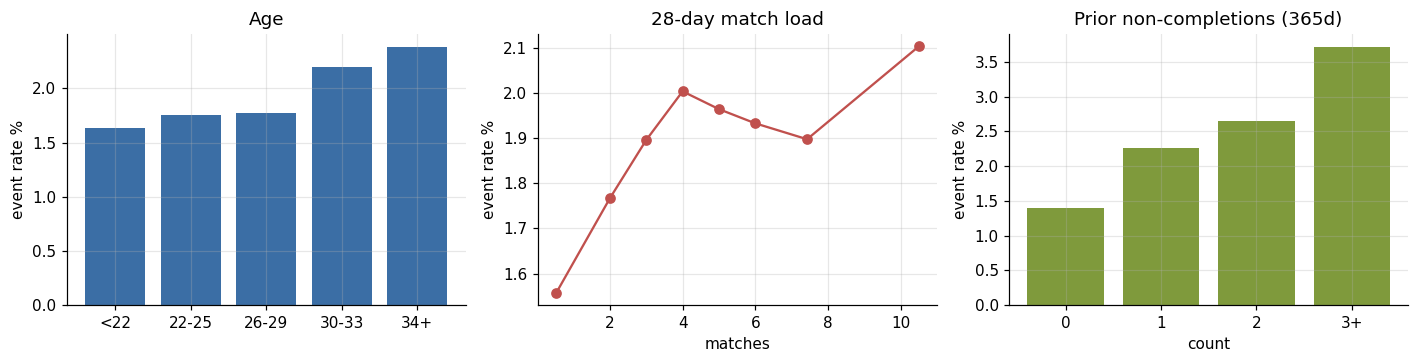

         mean   size
age                 
<22    0.0164  23029
22-25  0.0175  52880
26-29  0.0177  54470
30-33  0.0220  25852
34+    0.0238   7687

                     mean   size
prior_events_365d               
0.0                0.0140  99947
1.0                0.0226  40168
2.0                0.0266  16232
3.0                0.0371   7571


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

ab = pd.cut(df.age, [0,22,26,30,34,99], labels=P.AGE_LABELS, right=False)
g = df.groupby(ab, observed=True)[TARGET].agg(['mean','size'])
ax[0].bar(range(len(g)), g['mean']*100, color="#3b6ea5")
ax[0].set_xticks(range(len(g))); ax[0].set_xticklabels(g.index)
ax[0].set_title("Age"); ax[0].set_ylabel("event rate %")

d = df.groupby(pd.qcut(df.matches_28d, 8, duplicates='drop'), observed=True).agg(
    x=('matches_28d','mean'), y=(TARGET,'mean'))
ax[1].plot(d.x, d.y*100, 'o-', color="#c0504d")
ax[1].set_title("28-day match load"); ax[1].set_xlabel("matches"); ax[1].set_ylabel("event rate %")

pe = df.groupby(df.prior_events_365d.clip(upper=3))[TARGET].agg(['mean','size'])
ax[2].bar(range(len(pe)), pe['mean']*100, color="#7f9a3c")
ax[2].set_xticks(range(len(pe))); ax[2].set_xticklabels(['0','1','2','3+'])
ax[2].set_title("Prior non-completions (365d)"); ax[2].set_xlabel("count")
ax[2].set_ylabel("event rate %")
plt.tight_layout(); plt.show()

print(g.round(4)); print(); print(pe.round(4))

Age and prior injury history both show clean monotone gradients. The
workload gradient is weaker and noisier than the sports-science literature
would suggest - see section 5 for why (reverse causation).

## 3. Collinearity screen

In [4]:
vif = pd.read_csv(C.OUT_TAB / "vif_diagnostics.csv")
print(vif.head(10).round(2).to_string(index=False))

        feature   vif
    matches_28d 20.35
    minutes_28d 18.78
       log_rank 10.84
         hand_R  8.50
log_rank_points  8.16
     level_tour  6.94
      round_ord  6.54
    matches_90d  5.98
 career_matches  4.62
       tour_WTA  4.58


`matches_28d` and `minutes_28d` remain correlated (VIF ~20 and ~19). Both
are kept - they measure competition count versus court time - but their
individual coefficients are not separately identified and should be read
jointly. Everything with VIF > 30 was removed at the feature-selection stage
(METHODOLOGY section 4.2).

## 4. Validation protocol

Temporal holdout, not a random split: rows are repeated observations on the
same players, and the operational task is forecasting next season from past
seasons.

In [5]:
train, test = M.temporal_split(df)
print(f"train {len(train):,} rows  {train.season.min()}-{train.season.max()}")
print(f"test  {len(test):,} rows  {test.season.min()}-{test.season.max()}")

logit, m_tr, m_te, p_te = M.fit_and_score(M.make_logit(), train, test)
gbm, g_tr, g_te, p_gbm  = M.fit_and_score(M.make_gbm(),  train, test)

cols = ['auc_roc','pr_auc','brier','decile_lift','obs_over_pred',
        'accuracy_at_0.5','accuracy_predict_none']
pd.DataFrame({'logit train': m_tr, 'logit test': m_te, 'GBM test': g_te}).T[cols].round(4)

train 131,231 rows  2010-2022
test  32,687 rows  2023-2025


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,auc_roc,pr_auc,brier,decile_lift,obs_over_pred,accuracy_at_0.5,accuracy_predict_none
logit train,0.6325,0.0318,0.0180,5.4000,1.0004,0.9816,0.9816
logit test,0.6506,0.0399,0.0182,6.0000,1.0090,0.9814,0.9814
GBM test,0.6681,0.0404,0.0181,6.4783,1.0202,0.9814,0.9814


**Read the last two columns first.** The fitted model's accuracy (0.9814)
is *lower* than the accuracy of predicting no injury for every match (0.9816).
Accuracy is not a usable metric on this problem.

**Then read `obs_over_pred`.** 1.009 means the average predicted probability is
within 1% of observed frequency out of sample. That is the property that makes
the output a price rather than a score.

**Overfitting:** test AUC (0.651) exceeds train AUC (0.633). None detected.

**GBM:** higher AUC (0.668), identical PR-AUC, worse calibration (1.020). Not
worth the loss of interpretability for a rating model.

## 5. Coefficients

In [6]:
coefs = M.coefficient_table(logit)
print(coefs.head(16).round(4).to_string(index=False))

            feature  coefficient  odds_ratio
         level_team      -0.9186      0.3991
   level_grand_slam      -0.7767      0.4599
         level_tour      -0.6683      0.5126
      level_masters      -0.5063      0.6028
prior_events_career       0.2985      1.3478
     career_matches      -0.2189      0.8034
    log_rank_points      -0.1687      0.8448
          round_ord       0.1636      1.1777
       matches_365d      -0.1506      0.8602
             hand_U      -0.1365      0.8724
     level_olympics      -0.1304      0.8777
           log_rank      -0.1248      0.8826
  prior_events_365d       0.1239      1.1319
        minutes_28d       0.1237      1.1317
    days_since_last      -0.1149      0.8915
           tour_WTA       0.1033      1.1088


Numeric coefficients are per one standard deviation; categoricals are
against the dropped reference level.

- **`prior_events_career` (OR 1.35)** - the strongest player-level factor.
  Injury history repeats, consistent with the sports-medicine literature.
- **Tier effects dominate everything.** Grand Slams (OR 0.46) and team events
  (OR 0.40) show far fewer non-completions. This is plausibly *incentive*
  rather than physiology - prize money and ranking points are largest exactly
  where retirements are rarest - and if so, a model treating it as risk will
  underprice Grand Slam exposure. Flagged in METHODOLOGY section 7.1.
- **`matches_365d` (OR 0.86) runs the wrong way**: more tennis, less risk. This
  is the healthy-worker effect - fit players accumulate matches, injured
  players do not. The model is predictive, not causal. Nothing here supports
  advice to play more.

## 6. Calibration - the metric that matters for pricing

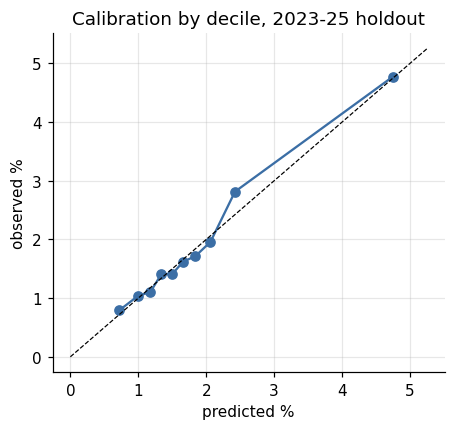

 bin    n  predicted  observed  ratio_obs_pred
   0 3269     0.0072    0.0080          1.0998
   1 3269     0.0100    0.0104          1.0416
   2 3268     0.0118    0.0110          0.9364
   3 3269     0.0134    0.0141          1.0515
   4 3269     0.0150    0.0141          0.9390
   5 3268     0.0166    0.0162          0.9771
   6 3269     0.0184    0.0171          0.9317
   7 3268     0.0206    0.0196          0.9494
   8 3269     0.0242    0.0281          1.1613
   9 3269     0.0475    0.0477          1.0056

Decile lift: 6.0x  (top 4.77% vs bottom 0.80%)


In [7]:
cal = M.calibration_table(test[TARGET].values, p_te)
fig, ax = plt.subplots(figsize=(4.6,4))
ax.plot(cal.predicted*100, cal.observed*100, 'o-', color="#3b6ea5")
lim = max(cal.predicted.max(), cal.observed.max())*100*1.1
ax.plot([0,lim],[0,lim],'k--',lw=.8)
ax.set_xlabel("predicted %"); ax.set_ylabel("observed %")
ax.set_title("Calibration by decile, 2023-25 holdout"); plt.show()
print(cal.round(4).to_string(index=False))
print(f"\nDecile lift: {m_te['decile_lift']:.1f}x  "
      f"(top {m_te['top_decile_rate']:.2%} vs bottom {m_te['bottom_decile_rate']:.2%})")

A 6x spread between the safest and riskiest tenth of the book, with
observed frequency tracking predicted within ~10% across every decile.

An AUC of 0.651 does not identify *which* player will get injured. It does
separate groups whose average frequency differs by a factor of six, and for
rating that is the requirement.

## 7. Pricing

In [8]:
sev = P.fit_severity(df)
res = json.load(open(C.OUT_TAB / "results_summary.json"))
mps = res["matches_per_season_median"]

print(f"P(major | event)   {sev['p_major']:.1%}   (observed)")
print(f"Cost, minor        GBP {sev['cost_minor']:,.0f}   (assumed, 5:1 ratio)")
print(f"Cost, major        GBP {sev['cost_major']:,.0f}")
print(f"Mean severity      GBP {sev['mean_severity']:,.0f}   (assumed)")
print()
print(f"Exposure basis: {mps:.1f} matches/season (match-weighted median)")
print(f"  vs naive per-player median of {res['matches_per_season_player_median']:.1f},")
print(f"  dominated by one-off qualifiers; using it would understate every")
print(f"  premium by a factor of {mps/res['matches_per_season_player_median']:.1f}.")

P(major | event)   9.8%   (observed)
Cost, minor        GBP 1,438   (assumed, 5:1 ratio)
Cost, major        GBP 7,188
Mean severity      GBP 2,000   (assumed)

Exposure basis: 30.8 matches/season (match-weighted median)
  vs naive per-player median of 5.7,
  dominated by one-off qualifiers; using it would understate every
  premium by a factor of 5.4.


In [9]:
tbl = pd.read_csv(C.OUT_TAB / "premium_table_age_x_load.csv")
tbl[['age_band','load_band','exposure_matches','observed_events','modelled_freq',
     'observed_freq','office_premium','ab_ratio','credibility']].round(4)

,age_band,load_band,exposure_matches,observed_events,modelled_freq,observed_freq,office_premium,ab_ratio,credibility
0,<22,light,1589,23,0.0152,0.0145,1080.2255,0.9502,0.1458
1,<22,moderate,1267,31,0.0166,0.0245,1178.9196,1.4718,0.1693
2,<22,heavy,1215,17,0.0160,0.0140,1132.6724,0.8760,0.1253
3,22-25,light,3585,51,0.0161,0.0142,1141.8070,0.8836,0.2171
4,22-25,moderate,3655,63,0.0183,0.0172,1295.2815,0.9437,0.2413
5,22-25,heavy,3401,70,0.0181,0.0206,1284.3161,1.1365,0.2544
6,26-29,light,3682,52,0.0169,0.0141,1198.3678,0.8358,0.2192
7,26-29,moderate,4181,75,0.0181,0.0179,1284.4741,0.9904,0.2633
8,26-29,heavy,3841,80,0.0166,0.0208,1174.8811,1.2572,0.2719
9,30-33,light,1952,44,0.0185,0.0225,1315.3439,1.2153,0.2017


**Read the `credibility` column before the `ab_ratio` column.** No cell
exceeds 0.27 credibility - full credibility needs ~1,082 claims and these cells
have 5 to 80. The 34+/heavy cell has an actual/expected of 0.47 on five claims,
which is noise rather than model failure. This is exactly why premiums come
from the fitted model rather than from cell-level experience.

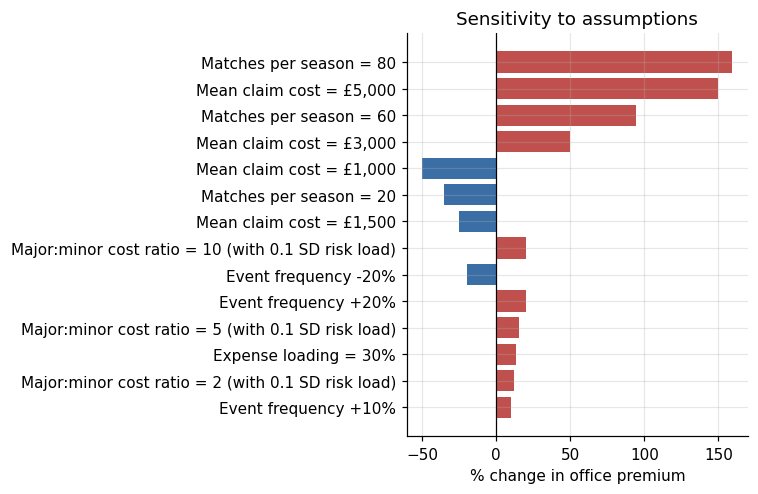

In [10]:
sens = pd.read_csv(C.OUT_TAB / "sensitivity_analysis.csv")
tor = sens[sens.scenario!="Base case"].copy()
tor = tor.reindex(tor.change_vs_base.abs().sort_values().index).tail(14)
fig, ax = plt.subplots(figsize=(7,4.6))
ax.barh(tor.scenario, tor.change_vs_base*100,
        color=["#c0504d" if v>0 else "#3b6ea5" for v in tor.change_vs_base])
ax.axvline(0, color='k', lw=.8); ax.set_xlabel("% change in office premium")
ax.set_title("Sensitivity to assumptions"); plt.tight_layout(); plt.show()

**The conclusion of the whole project is in this chart.**

The two largest bars are mean claim cost and matches per season - and *neither
is estimated by the model*. One is asserted; the other is a forecast of the
player's schedule. Improving AUC from 0.65 to 0.70 would move premiums by a few
percent. Being wrong about the claim cost by a factor of two moves them by a
factor of two.

For this product the statistical model is not the binding constraint on pricing
accuracy. Identifying that is worth more than another decimal of AUC.

## 8. Uncertainty

Two sources, quantified separately: how well the *rate* is known (parameter
uncertainty, from the Fisher information) and how well the *portfolio average*
is known (bootstrap over players, not rows).

In [11]:
print(f"Mean pure premium  GBP {res['mean_pp_ci'][1]:,.0f}  "
      f"(95% CI {res['mean_pp_ci'][0]:,.0f} - {res['mean_pp_ci'][2]:,.0f})")
print(f"Median relative CI width: {res['median_relative_ci_width']:.0%} of the estimate")
print()
b = res['portfolio_bootstrap']
print(f"Portfolio mean     GBP {b['mean']:,.0f}  (95% CI {b['lo95']:,.0f} - {b['hi95']:,.0f})")

Mean pure premium  GBP 1,160  (95% CI 927 - 1,456)
Median relative CI width: 42% of the estimate

Portfolio mean     GBP 1,166  (95% CI 1,041 - 1,313)


A +/-42% interval on an individual rate is wide, and should be reported
that way rather than smoothed over. The portfolio interval is much tighter
(+/-12%) because errors diversify across players - which is the actuarial
point: this product is priceable at book level and barely priceable at
individual level.

Process variance - the volatility of one player's actual year - is larger than
both, and is what the risk loading exists to cover.